<a href="https://colab.research.google.com/github/harmanbajwa2954/MRI_Brain_Tumor_Detection/blob/main/Type_of_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Type of Brain Tumor Detection using MRI images**

## Importing Libraries and Tools

In [1]:
!git clone https://github.com/harmanbajwa2954/MRI_Brain_Tumor_Detection.git

Cloning into 'MRI_Brain_Tumor_Detection'...
remote: Enumerating objects: 7212, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 7212 (delta 0), reused 0 (delta 0), pack-reused 7211 (from 3)
Receiving objects: 100% (7212/7212), 154.18 MiB | 23.23 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (7456/7456), done.


In [2]:
import os #for directory and file operations
import numpy as np
import random
from PIL import Image, ImageEnhance # Pillow library used to work with images

#keras
from tensorflow.keras.models import Sequential  #for building the model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout  # for model layers
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam    #for optimization
from tensorflow.keras.applications import VGG16 # for using VGG16 model

from sklearn.utils import shuffle # for shuffling the data

## Load Datasets

In [3]:
# Directories for training and testing data
train_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Training/'
test_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/'

#laod and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

## Data Visualization

In [4]:
import matplotlib.pyplot as plt

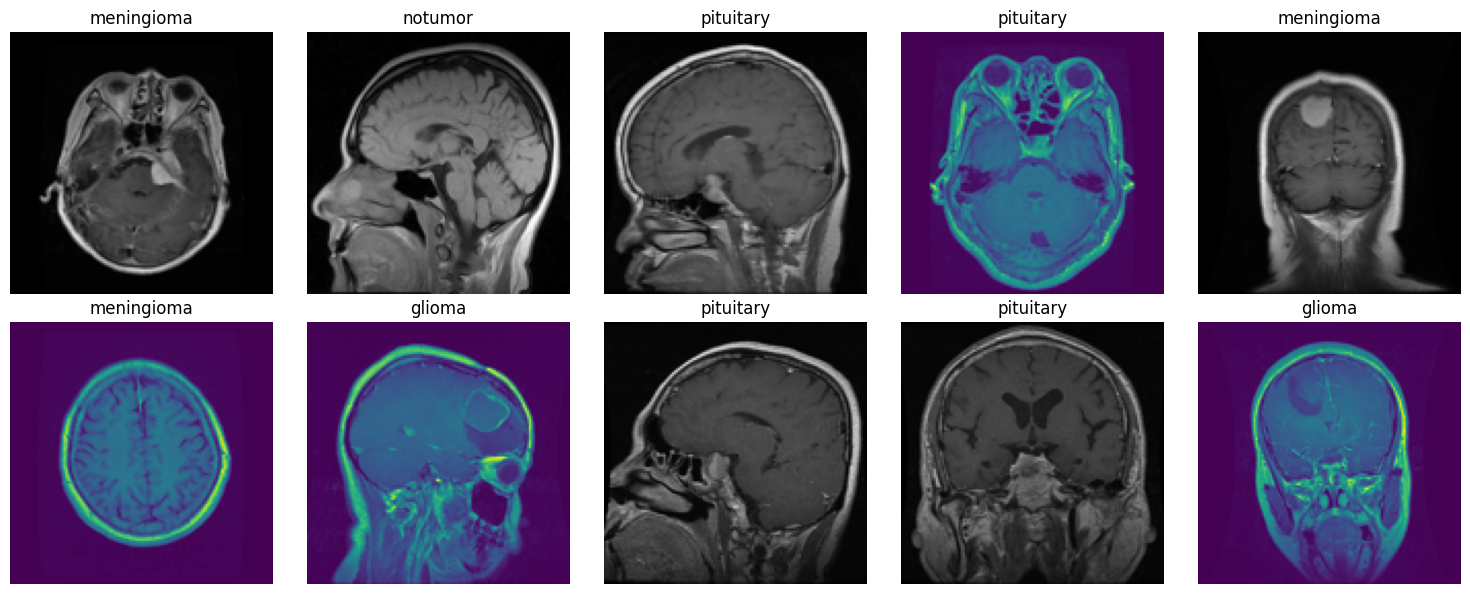

In [5]:
#selecting random incies for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))

  #Display images inside the loop
  axes[i].imshow(img)
  axes[i].set_title(train_labels[idx]) # Add title with label
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## Image Preprocessing (Helper Functions)

In [6]:
from numpy._core.defchararray import encode
#image augmentation fucntion
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image

#Load images and apply augmentation
def open_images(path):
  image = []
  for img_path in path:
    img = load_img(img_path, target_size=(128,128))
    img = augment_image(img)
    image.append(img)

  return np.array(image)


#Encoder labels : converts label names to integers
def encode_label(labels):
  unique_labels = os.listdir(train_dir)
  encoded = [unique_labels.index(label) for label in unique_labels]
  return encode

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
  for _ in range(epochs):
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, batch_labels

## **MODEL**

Here for this project we are going to use **VGG16** for Transfer Learning.

> **VGG16** is a pre-trained convolutional neural network (CNN) for image classification.

In [ ]:
# Model Architecture (128,128,3)
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weigth='imagenet')

# freezing all layers of the VGG16 base model
for layer in base_model.layers:
  layer.trainable = False

# set only the last few layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

#Building model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))) #input layer
model.add(base_model) #VGG16 model
model.add(Flatten()) #flatten layer
model.add(Dropout(0.3))  # this layer randomly drops 30% of neurons to save model from overfitting

model.add(Dense(128, activation='relu')) #hidden layer
model.add(Dropout(0.2))

model.add(Dense(len((os.listdir(train_dir))),activation='softmax')) #output layer

#Compiling the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

#Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 10

#train model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    steps_per_epoch=steps,

)